Block 1 — Imports and Configuration

In [4]:
import os
import shutil
import random

# Path to the original folder with 200 images
original_folder = "../../data/leaf/RiceLeafsDisease/test_aug"

# Destination folders
test_folder = "../../data/leaf/RiceLeafsDisease/test_aug_new"          # We'll move half of the images here
validation_folder = "../../data/leaf/RiceLeafsDisease/validation_aug"


# Create destination folders if they don't exist
os.makedirs(test_folder, exist_ok=True)
os.makedirs(validation_folder, exist_ok=True)

# Loop through each class folder
for class_name in os.listdir(original_folder):
    class_path = os.path.join(original_folder, class_name)
    if os.path.isdir(class_path):
        # Make class subfolders in destination folders
        os.makedirs(os.path.join(test_folder, class_name), exist_ok=True)
        os.makedirs(os.path.join(validation_folder, class_name), exist_ok=True)
        
        # List all images in this class
        images = [f for f in os.listdir(class_path) if os.path.isfile(os.path.join(class_path, f))]
        random.shuffle(images)
        
        # Split in half
        half = len(images) // 2
        validation_images = images[:half]
        test_images = images[half:]
        
        # Move images
        for img in validation_images:
            shutil.move(os.path.join(class_path, img), os.path.join(validation_folder, class_name, img))
        for img in test_images:
            shutil.move(os.path.join(class_path, img), os.path.join(test_folder, class_name, img))

print("Splitting done: each class split 50/50 into test and validation folders.")



Splitting done: each class split 50/50 into test and validation folders.


In [12]:
import os
import random
from PIL import Image, ImageEnhance

TARGET_COUNT = 500
IMAGE_EXTS = (".jpg", ".jpeg", ".png")

def augment_image(img):
    """Apply one random augmentation (no cropping)"""
    ops = []

    # Flips
    ops.append(lambda x: x.transpose(Image.FLIP_LEFT_RIGHT))
    ops.append(lambda x: x.transpose(Image.FLIP_TOP_BOTTOM))

    # Rotations
    ops.append(lambda x: x.rotate(90, expand=True))
    ops.append(lambda x: x.rotate(180, expand=True))
    ops.append(lambda x: x.rotate(270, expand=True))

    # Brightness
    ops.append(lambda x: ImageEnhance.Brightness(x).enhance(random.uniform(0.7, 1.3)))

    # Contrast
    ops.append(lambda x: ImageEnhance.Contrast(x).enhance(random.uniform(0.7, 1.3)))

    # Color (saturation)
    ops.append(lambda x: ImageEnhance.Color(x).enhance(random.uniform(0.7, 1.3)))

    # Sharpness
    ops.append(lambda x: ImageEnhance.Sharpness(x).enhance(random.uniform(0.8, 1.5)))

    op = random.choice(ops)
    return op(img)


def augment_test_folder(test_root):
    for class_name in os.listdir(test_root):
        class_path = os.path.join(test_root, class_name)
        if not os.path.isdir(class_path):
            continue

        images = [f for f in os.listdir(class_path) if f.lower().endswith(IMAGE_EXTS)]
        count = len(images)

        print(f"\nClass: {class_name} | Current: {count}")

        if count >= TARGET_COUNT:
            print("Already sufficient, skipping.")
            continue

        i = 0
        while count < TARGET_COUNT:
            img_name = random.choice(images)
            img_path = os.path.join(class_path, img_name)

            try:
                img = Image.open(img_path).convert("RGB")
                aug_img = augment_image(img)

                new_name = f"aug_{i}_{img_name}"
                save_path = os.path.join(class_path, new_name)

                aug_img.save(save_path, quality=95)
                count += 1
                i += 1

                print(f"Added: {new_name} | Total: {count}")

            except Exception as e:
                print(f"Error augmenting {img_name}: {e}")

        print(f"✅ Final count for {class_name}: {count}")


# =========================
# RUN
# =========================
validation_folder = "../../data/leaf/riceLeafsDisease/validation_aug"
augment_test_folder(validation_folder)



Class: bacterial_leaf_blight | Current: 490
Added: aug_0_aug_37_bacterial_val (47).jpg | Total: 491
Added: aug_1_aug_444_bacterial_val (22).JPG | Total: 492
Added: aug_2_aug_205_bacterial_val (20).JPG | Total: 493
Added: aug_3_aug_73_bacterial_val (49).jpg | Total: 494
Added: aug_4_aug_95_bacterial_val (40).JPG | Total: 495
Added: aug_5_aug_162_bacterial_val (25).JPG | Total: 496
Added: aug_6_aug_236_bacterial_val (70).JPG | Total: 497
Added: aug_7_bacterial_val (28).JPG | Total: 498
Added: aug_8_aug_90_bacterial_val (20).JPG | Total: 499
Added: aug_9_bacterial_val (40).JPG | Total: 500
✅ Final count for bacterial_leaf_blight: 500

Class: brown_spot | Current: 482
Added: aug_0_aug_448_brown_val (21).JPG | Total: 483
Added: aug_1_aug_355_brown_val (4).jpg | Total: 484
Added: aug_2_aug_146_brown_val (30).jpg | Total: 485
Added: aug_3_aug_163_brown_val (33).jpg | Total: 486
Added: aug_4_aug_331_brown_val (41).jpg | Total: 487
Added: aug_5_aug_40_brown_val (41).jpg | Total: 488
Added: aug

In [10]:
import os
import random
from PIL import Image, ImageEnhance

TARGET_COUNT = 500
IMAGE_EXTS = (".jpg", ".jpeg", ".png")

def augment_image(img):
    """Apply one random augmentation (no cropping)"""
    ops = []

    # Flips
    ops.append(lambda x: x.transpose(Image.FLIP_LEFT_RIGHT))
    ops.append(lambda x: x.transpose(Image.FLIP_TOP_BOTTOM))

    # Rotations
    ops.append(lambda x: x.rotate(90, expand=True))
    ops.append(lambda x: x.rotate(180, expand=True))
    ops.append(lambda x: x.rotate(270, expand=True))

    # Brightness
    ops.append(lambda x: ImageEnhance.Brightness(x).enhance(random.uniform(0.7, 1.3)))

    # Contrast
    ops.append(lambda x: ImageEnhance.Contrast(x).enhance(random.uniform(0.7, 1.3)))

    # Color (saturation)
    ops.append(lambda x: ImageEnhance.Color(x).enhance(random.uniform(0.7, 1.3)))

    # Sharpness
    ops.append(lambda x: ImageEnhance.Sharpness(x).enhance(random.uniform(0.8, 1.5)))

    op = random.choice(ops)
    return op(img)


def augment_test_folder(test_root):
    for class_name in os.listdir(test_root):
        class_path = os.path.join(test_root, class_name)
        if not os.path.isdir(class_path):
            continue

        images = [f for f in os.listdir(class_path) if f.lower().endswith(IMAGE_EXTS)]
        count = len(images)

        print(f"\nClass: {class_name} | Current: {count}")

        if count >= TARGET_COUNT:
            print("Already sufficient, skipping.")
            continue

        i = 0
        while count < TARGET_COUNT:
            img_name = random.choice(images)
            img_path = os.path.join(class_path, img_name)

            try:
                img = Image.open(img_path).convert("RGB")
                aug_img = augment_image(img)

                new_name = f"aug_{i}_{img_name}"
                save_path = os.path.join(class_path, new_name)

                aug_img.save(save_path, quality=95)
                count += 1
                i += 1

                print(f"Added: {new_name} | Total: {count}")

            except Exception as e:
                print(f"Error augmenting {img_name}: {e}")

        print(f"✅ Final count for {class_name}: {count}")


# =========================
# RUN
# =========================
test_folder = "../../data/leaf/riceLeafsDisease/test_aug_new"
augment_test_folder(test_folder)



Class: bacterial_leaf_blight | Current: 423
Added: aug_0_aug_97_bacterial_val (38).JPG | Total: 424
Added: aug_1_aug_361_bacterial_val (31).JPG | Total: 425
Added: aug_2_aug_216_bacterial_val (52).JPG | Total: 426
Added: aug_3_aug_103_bacterial_val (63).JPG | Total: 427
Added: aug_4_aug_309_bacterial_val (53).JPG | Total: 428
Added: aug_5_bacterial_val (84).jpg | Total: 429
Added: aug_6_aug_219_bacterial_val (18).JPG | Total: 430
Added: aug_7_aug_169_bacterial_val (50).JPG | Total: 431
Added: aug_8_aug_53_bacterial_val (65).JPG | Total: 432
Added: aug_9_aug_133_bacterial_val (11).JPG | Total: 433
Added: aug_10_aug_145_bacterial_val (76).JPG | Total: 434
Added: aug_11_aug_109_bacterial_val (59).JPG | Total: 435
Added: aug_12_bacterial_val (21).JPG | Total: 436
Added: aug_13_aug_179_bacterial_val (19).jpg | Total: 437
Added: aug_14_aug_174_bacterial_val (7).JPG | Total: 438
Added: aug_15_aug_248_bacterial_val (39).JPG | Total: 439
Added: aug_16_aug_260_bacterial_val (51).JPG | Total: 44

In [8]:
import os
from PIL import Image
import imagehash

def get_image_hashes(folder):
    """Compute phash for all images in a folder (including subfolders)"""
    hashes = {}
    for root, _, files in os.walk(folder):
        for file in files:
            if file.lower().endswith((".jpg", ".png", ".jpeg")):
                path = os.path.join(root, file)
                try:
                    img = Image.open(path).convert("RGB")
                    h = imagehash.phash(img)
                    hashes.setdefault(h, []).append(path)
                except Exception as e:
                    print(f"Error reading {path}: {e}")
    return hashes

def remove_duplicates(hashes_source, hashes_target, source_name, target_name):
    """Remove images from target if duplicate exists in source"""
    common_hashes = set(hashes_source.keys()) & set(hashes_target.keys())
    print(f"Duplicates between {source_name} and {target_name}: {len(common_hashes)}")
    deleted_count = 0
    for h in common_hashes:
        for target_path in hashes_target[h]:
            try:
                os.remove(target_path)
                print(f"Deleted from {target_name}: {target_path}")
                deleted_count += 1
            except Exception as e:
                print(f"Failed to delete {target_path}: {e}")
    return deleted_count

# Folders
TRAIN_DIR = "../../data/leaf/riceLeafsDisease/train_aug"
TEST_DIR  = "../../data/leaf/riceLeafsDisease/test_aug_new"
VAL_DIR   = "../../data/leaf/riceLeafsDisease/validation_aug"

# Compute hashes
train_hashes = get_image_hashes(TRAIN_DIR)
test_hashes  = get_image_hashes(TEST_DIR)
val_hashes   = get_image_hashes(VAL_DIR)

# 1️⃣ Remove duplicates from test if they exist in train
remove_duplicates(train_hashes, test_hashes, "Train", "Test")

# 2️⃣ Remove duplicates from validation if they exist in train
remove_duplicates(train_hashes, val_hashes, "Train", "Validation")

# 3️⃣ Remove duplicates from validation if they exist in test
remove_duplicates(test_hashes, val_hashes, "Test", "Validation")

print("Dataset cleanup completed. Train remains intact; Test and Validation cleaned of duplicates.")


Duplicates between Train and Test: 0
Duplicates between Train and Validation: 0
Duplicates between Test and Validation: 27
Deleted from Validation: ../../data/leaf/riceLeafsDisease/validation_aug\leaf_scald\aug_246_leaf_scald_val (79).jpg
Deleted from Validation: ../../data/leaf/riceLeafsDisease/validation_aug\leaf_scald\aug_95_leaf_scald_val (79).jpg
Deleted from Validation: ../../data/leaf/riceLeafsDisease/validation_aug\leaf_blast\aug_431_leaf_blast_val (17).jpg
Deleted from Validation: ../../data/leaf/riceLeafsDisease/validation_aug\bacterial_leaf_blight\aug_122_bacterial_val (20).JPG
Deleted from Validation: ../../data/leaf/riceLeafsDisease/validation_aug\bacterial_leaf_blight\aug_140_bacterial_val (20).JPG
Deleted from Validation: ../../data/leaf/riceLeafsDisease/validation_aug\bacterial_leaf_blight\aug_312_bacterial_val (20).JPG
Deleted from Validation: ../../data/leaf/riceLeafsDisease/validation_aug\leaf_blast\aug_140_leaf_blast_val (58).jpg
Deleted from Validation: ../../data/

In [13]:
import os
from PIL import Image
import imagehash

def get_image_hashes(folder):
    """Compute phash for all images in a folder (including subfolders)"""
    hashes = {}
    for root, _, files in os.walk(folder):
        for file in files:
            if file.lower().endswith((".jpg", ".png", ".jpeg")):
                path = os.path.join(root, file)
                try:
                    img = Image.open(path).convert("RGB")
                    h = imagehash.phash(img)
                    hashes.setdefault(h, []).append(path)
                except Exception as e:
                    print(f"Error reading {path}: {e}")
    return hashes

def remove_duplicates(hashes_source, hashes_target, source_name, target_name):
    """Remove images from target if duplicate exists in source"""
    common_hashes = set(hashes_source.keys()) & set(hashes_target.keys())
    print(f"Duplicates between {source_name} and {target_name}: {len(common_hashes)}")
    deleted_count = 0
    for h in common_hashes:
        for target_path in hashes_target[h]:
            try:
                os.remove(target_path)
                print(f"Deleted from {target_name}: {target_path}")
                deleted_count += 1
            except Exception as e:
                print(f"Failed to delete {target_path}: {e}")
    return deleted_count

# Folders
TRAIN_DIR = "../../data/leaf/riceLeafsDisease/train_aug"
TEST_DIR  = "../../data/leaf/riceLeafsDisease/test_aug_new"
VAL_DIR   = "../../data/leaf/riceLeafsDisease/validation_aug"

# Compute hashes
train_hashes = get_image_hashes(TRAIN_DIR)
test_hashes  = get_image_hashes(TEST_DIR)
val_hashes   = get_image_hashes(VAL_DIR)

# 1️⃣ Remove duplicates from test if they exist in train
remove_duplicates(train_hashes, test_hashes, "Train", "Test")

# 2️⃣ Remove duplicates from validation if they exist in train
remove_duplicates(train_hashes, val_hashes, "Train", "Validation")

# 3️⃣ Remove duplicates from validation if they exist in test
remove_duplicates(test_hashes, val_hashes, "Test", "Validation")

print("Dataset cleanup completed. Train remains intact; Test and Validation cleaned of duplicates.")


Duplicates between Train and Test: 0
Duplicates between Train and Validation: 0
Duplicates between Test and Validation: 10
Deleted from Validation: ../../data/leaf/riceLeafsDisease/validation_aug\leaf_blast\aug_53_aug_364_leaf_blast_val (57).jpg
Deleted from Validation: ../../data/leaf/riceLeafsDisease/validation_aug\bacterial_leaf_blight\aug_7_bacterial_val (28).JPG
Deleted from Validation: ../../data/leaf/riceLeafsDisease/validation_aug\leaf_blast\aug_1_aug_38_leaf_blast_val (12).jpg
Deleted from Validation: ../../data/leaf/riceLeafsDisease/validation_aug\leaf_scald\aug_18_aug_406_leaf_scald_val (79).jpg
Deleted from Validation: ../../data/leaf/riceLeafsDisease/validation_aug\leaf_blast\aug_37_aug_28_leaf_blast_val (17).jpg
Deleted from Validation: ../../data/leaf/riceLeafsDisease/validation_aug\narrow_brown_spot\aug_73_aug_391_narrow_brown_val (77).jpg
Deleted from Validation: ../../data/leaf/riceLeafsDisease/validation_aug\leaf_blast\aug_3_aug_413_leaf_blast_val (88).jpg
Deleted fr

In [14]:
import os
import random
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

from torchvision import datasets, transforms
import timm

from PIL import Image
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


In [25]:
# -----------------------------
# Paths
# -----------------------------
DATA_ROOT = "../../data/Leaf/RiceLeafsDisease"

TRAIN_DIR = os.path.join(DATA_ROOT, "train_aug")
VAL_DIR   = os.path.join(DATA_ROOT, "validation_aug")
TEST_DIR  = os.path.join(DATA_ROOT, "test_aug_new")

OUT_DIR = "./outputs_vit_final_2500"
os.makedirs(OUT_DIR, exist_ok=True)

# -----------------------------
# Device & seed
# -----------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 42

torch.manual_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)


In [36]:
# NUM_CLASSES = 6
# IMG_SIZE = 224
# BATCH_SIZE = 12
# EPOCHS = 8
# NUM_WORKERS = 2
# ACCUM_STEPS = 1

# # Hyperparameter sweep (FINAL)
# LR_LIST = [3e-5]
# WEIGHT_DECAY_LIST = [5e-4]
# LABEL_SMOOTHING_LIST = [0.1]
# DROPOUT_LIST = [0.0]


In [27]:
def get_transforms(img_size, train=True):
    if train:
        return transforms.Compose([
            transforms.RandomResizedCrop(img_size, scale=(0.6, 1.0)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.RandomRotation(15),
            transforms.ColorJitter(0.2, 0.2, 0.15, 0.02),
            transforms.ToTensor(),
            transforms.Normalize(
                [0.485, 0.456, 0.406],
                [0.229, 0.224, 0.225]
            ),
        ])
    else:
        return transforms.Compose([
            transforms.Resize(int(img_size * 1.14)),
            transforms.CenterCrop(img_size),
            transforms.ToTensor(),
            transforms.Normalize(
                [0.485, 0.456, 0.406],
                [0.229, 0.224, 0.225]
            ),
        ])


In [28]:
def load_dataloaders():
    train_ds = datasets.ImageFolder(
        TRAIN_DIR, transform=get_transforms(IMG_SIZE, train=True)
    )
    val_ds = datasets.ImageFolder(
        VAL_DIR, transform=get_transforms(IMG_SIZE, train=False)
    )
    test_ds = datasets.ImageFolder(
        TEST_DIR, transform=get_transforms(IMG_SIZE, train=False)
    )

    train_loader = DataLoader(
        train_ds, batch_size=BATCH_SIZE,
        shuffle=True, num_workers=NUM_WORKERS
    )
    val_loader = DataLoader(
        val_ds, batch_size=BATCH_SIZE,
        shuffle=False, num_workers=NUM_WORKERS
    )
    test_loader = DataLoader(
        test_ds, batch_size=BATCH_SIZE,
        shuffle=False, num_workers=NUM_WORKERS
    )

    print("Classes:", train_ds.classes)
    return train_loader, val_loader, test_loader, train_ds.classes


In [29]:
class UnlabeledDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.paths = sorted([
            p for p in Path(root_dir).iterdir()
            if p.suffix.lower() in [".jpg", ".png", ".jpeg"]
        ])
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, str(self.paths[idx])


In [30]:
def build_model(num_classes, dropout):
    model = timm.create_model(
        "vit_tiny_patch16_224",
        pretrained=True,
        num_classes=num_classes,
        drop_rate=dropout
    )
    return model


In [31]:
def train_one_epoch(model, loader, criterion, optimizer, scaler):
    model.train()
    loss_sum, correct, total = 0, 0, 0
    optimizer.zero_grad()

    for imgs, labels in tqdm(loader, leave=False):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)

        with torch.cuda.amp.autocast():
            outputs = model(imgs)
            loss = criterion(outputs, labels) / ACCUM_STEPS

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad()

        loss_sum += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)

    return loss_sum / len(loader), correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    loss_sum, correct, total = 0, 0, 0

    for imgs, labels in tqdm(loader, leave=False):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        outputs = model(imgs)
        loss = criterion(outputs, labels)

        loss_sum += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)

    return loss_sum / len(loader), correct / total


In [32]:
train_loader, val_loader, test_loader, class_names = load_dataloaders()


Classes: ['bacterial_leaf_blight', 'brown_spot', 'healthy', 'leaf_blast', 'leaf_scald', 'narrow_brown_spot']


In [37]:
NUM_CLASSES = 6
IMG_SIZE = 224
BATCH_SIZE = 12
EPOCHS = 8
NUM_WORKERS = 2
ACCUM_STEPS = 1

# Selected final hyperparameters
LR = 3e-5
WEIGHT_DECAY = 5e-4
LABEL_SMOOTHING = 0.1
DROPOUT = 0.2

train_loader, val_loader, test_loader, class_names = load_dataloaders()

# Initialize model
model = build_model(NUM_CLASSES, DROPOUT).to(DEVICE)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
scaler = torch.cuda.amp.GradScaler()

BEST_VAL_ACC = 0.0
BEST_MODEL_PATH = None

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, scaler)
    val_loss, val_acc = evaluate(model, val_loader, criterion)

    print(
        f"Epoch {epoch+1}: "
        f"Train Acc={train_acc*100:.2f}% | "
        f"Val Acc={val_acc*100:.2f}%"
    )

    # Save best model based on validation accuracy
    if val_acc > BEST_VAL_ACC:
        BEST_VAL_ACC = val_acc
        BEST_MODEL_PATH = os.path.join(OUT_DIR, "vit_best.pt")
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print(f"Saved new best model with Val Acc={val_acc*100:.2f}% at {BEST_MODEL_PATH}")

# Optionally, you can evaluate on test set after training
test_loss, test_acc = evaluate(model, test_loader, criterion)
print(f"Test Accuracy: {test_acc*100:.2f}%")


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x00000211A81D5BC0>
Traceback (most recent call last):
  File "c:\Users\Acer\.conda\envs\nlp-env\Lib\site-packages\torch\utils\data\dataloader.py", line 1663, in __del__
    self._shutdown_workers()
  File "c:\Users\Acer\.conda\envs\nlp-env\Lib\site-packages\torch\utils\data\dataloader.py", line 1621, in _shutdown_workers
    if self._persistent_workers or self._workers_status[worker_id]:
                                   ^^^^^^^^^^^^^^^^^^^^
AttributeError: '_MultiProcessingDataLoaderIter' object has no attribute '_workers_status'
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x00000211A81D5BC0>
Traceback (most recent call last):
  File "c:\Users\Acer\.conda\envs\nlp-env\Lib\site-packages\torch\utils\data\dataloader.py", line 1663, in __del__
    self._shutdown_workers()
  File "c:\Users\Acer\.conda\envs\nlp-env\Lib\site-packages\torch\utils\data\dataloader.py", line 1621, in _shutdo

Classes: ['bacterial_leaf_blight', 'brown_spot', 'healthy', 'leaf_blast', 'leaf_scald', 'narrow_brown_spot']


C:\Users\Acer\AppData\Local\Temp\ipykernel_17652\2882951674.py:20: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
  0%|          | 0/1250 [00:00<?, ?it/s]C:\Users\Acer\AppData\Local\Temp\ipykernel_17652\4269703485.py:9: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 1: Train Acc=89.67% | Val Acc=88.49%
Saved new best model with Val Acc=88.49% at ./outputs_vit_final_2500\vit_best.pt


Epoch 2: Train Acc=97.14% | Val Acc=90.87%
Saved new best model with Val Acc=90.87% at ./outputs_vit_final_2500\vit_best.pt


...

Epoch 5: Train Acc=98.39% | Val Acc=90.80%


Epoch 6: Train Acc=98.85% | Val Acc=91.40%
Saved new best model with Val Acc=91.40% at ./outputs_vit_final_2500\vit_best.pt


Epoch 7: Train Acc=99.02% | Val Acc=90.60%


Epoch 8: Train Acc=98.87% | Val Acc=91.17%


Test Accuracy: 93.50%


In [45]:
from timm import create_model

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = create_model(
    "vit_tiny_patch16_224",   # ← EXACT same model
    pretrained=False,
    num_classes=NUM_CLASSES  # ← SAME as training
)

model = model.to(device)

import torch
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import matplotlib.pyplot as plt

# load best model
checkpoint = torch.load("outputs_vit_final_2500/vit_best.pt")
model.load_state_dict(checkpoint)
model.eval()


import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import torch

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

all_preds = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)

# Test accuracy
test_acc = accuracy_score(all_labels, all_preds)
print(f"TEST Accuracy: {test_acc * 100:.2f}%")




TEST Accuracy: 91.83%


VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 192, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=192, out_features=576, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (proj): Linear(in_features=192, out_features=192, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=192, out_features=768, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False)


VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 192, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=192, out_features=576, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (proj): Linear(in_features=192, out_features=192, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=192, out_features=768, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False)


In [46]:
cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:\n", cm)


Confusion Matrix:
 [[484   1   1  12   0   2]
 [  0 451  34  15   0   0]
 [  0   2 498   0   0   0]
 [  0  15  23 462   0   0]
 [ 18   0   0  79 403   0]
 [  0  27   5  11   0 457]]


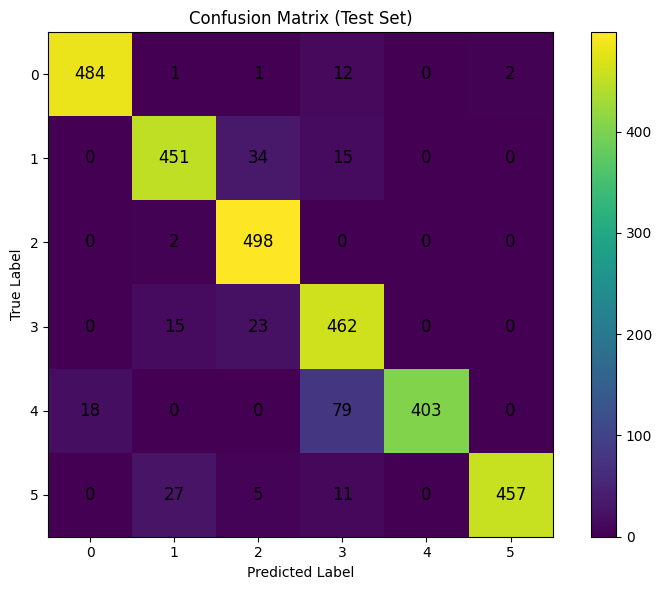

In [47]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8, 6))
plt.imshow(cm)
plt.colorbar()
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (Test Set)")

# Add numbers inside each cell
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i, cm[i, j],
            ha="center", va="center",
            fontsize=12
        )

plt.tight_layout()
plt.show()


IndexError: list index out of range

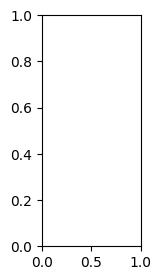

In [50]:
import matplotlib.pyplot as plt
import numpy as np

def show_misclassified(images, true_labels, pred_labels, class_a, class_b, n=8):
    """
    Show images where true = class_a but predicted = class_b
    """
    idxs = np.where((true_labels == class_a) & (pred_labels == class_b))[0]
    idxs = idxs[:n]

    plt.figure(figsize=(12, 3))
    for i, idx in enumerate(idxs):
        plt.subplot(1, n, i+1)
        plt.imshow(images[idx])
        plt.axis("off")
        plt.title(f"T:{class_a} → P:{class_b}")
    plt.show()

# Example:
show_misclassified(validation_images, all_labels, all_preds, class_a=4, class_b=3)


In [45]:
import json

config = {
    "architecture": "vit_tiny_patch16_224",
    "num_classes": 6,
    "img_size": 224,
    "best_epoch": 8,
    "learning_rate": 3e-05,
    "weight_decay": 0.0005,
    "label_smoothing": 0.1,
    "dropout": 0.0,
    "val_accuracy": 0.9924,
    "test_accuracy": 0.97
}

with open("vit_best_config.json", "w") as f:
    json.dump(config, f, indent=4)


In [46]:
class_names = [
    "bacterial_leaf_blight",
    "brown_spot",
    "healthy",
    "leaf_blast",
    "leaf_scald",
    "narrow_brown_spot"
]

with open("class_names.txt", "w") as f:
    for c in class_names:
        f.write(c + "\n")


In [57]:
from pillow_heif import register_heif_opener
register_heif_opener()


In [58]:
import torch
from timm import create_model

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

NUM_CLASSES = 6

model = create_model(
    "vit_tiny_patch16_224",
    pretrained=False,
    num_classes=NUM_CLASSES
)

model.load_state_dict(torch.load("outputs_vit_final/vit_best.pt", map_location=device))
model.to(device)
model.eval()


VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 192, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=192, out_features=576, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (proj): Linear(in_features=192, out_features=192, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=192, out_features=768, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False)


In [59]:
import os
from PIL import Image
from torch.utils.data import Dataset

class UnlabeledImageDataset(Dataset):
    def __init__(self, image_dir, transform=None):
        self.image_dir = image_dir
        self.transform = transform
        self.images = sorted([
            os.path.join(image_dir, f)
            for f in os.listdir(image_dir)
            if f.lower().endswith((".jpg", ".png", ".jpeg", ".heic", ".heif"))
        ])

        print(f"Found {len(self.images)} images")

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = Image.open(self.images[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img


In [65]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

field_dataset = UnlabeledImageDataset(
    image_dir="../../data/collected_data",
    transform=transform
)

field_loader = DataLoader(
    field_dataset,
    batch_size=32,
    shuffle=False
)


Found 202 images


In [66]:
import numpy as np
import torch

predicted_labels = []

model.eval()
with torch.no_grad():
    for images in field_loader:
        images = images.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)
        predicted_labels.extend(preds.cpu().numpy())

predicted_labels = np.array(predicted_labels)
print(predicted_labels)


[3 2 3 3 3 3 3 4 4 3 3 3 4 3 3 3 3 3 3 2 2 3 3 3 3 3 2 3 3 3 3 3 3 3 2 2 3
 3 3 2 3 3 2 3 3 3 2 3 3 2 2 3 2 3 2 3 3 2 3 3 3 2 3 3 3 2 3 3 3 3 3 3 3 3
 2 3 2 3 3 3 3 3 3 2 3 3 3 3 3 3 3 3 3 3 3 3 3 3 2 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 3 3 3 3 2 3 3 3 3 3 3 3 3 3 2 3 3 3 3 3 3 3 3 2 3 3 3 3 3 3 3 3 3 3
 3 3 3 3 3 3 3 3 2 2 3 2 3 2 2 3 3 3 3 3 3 3 3 3 2 2 3 2 2 2 3 3 2 2 3 3 3
 2 3 3 2 2 2 2 2 3 2 3 3 3 2 3 3 3]


In [70]:
import os
from PIL import Image
import imagehash

def get_image_hashes(folder):
    hashes = {}
    for root, _, files in os.walk(folder):
        for file in files:
            if file.lower().endswith((".jpg", ".png", ".jpeg")):
                path = os.path.join(root, file)
                try:
                    img = Image.open(path).convert("RGB")
                    h = imagehash.phash(img)  # perceptual hash
                    hashes[h] = path
                except Exception as e:
                    print(f"Error reading {path}: {e}")
    return hashes

train_hashes = get_image_hashes("../../data/leaf/riceLeafsDisease/train")
test_hashes  = get_image_hashes("../../data/leaf/riceLeafsDisease/test")

# Find common images
common = set(train_hashes.keys()) & set(test_hashes.keys())

print(f"Matching images found: {len(common)}")

for h in list(common)[:10]:  # show first 10
    print("TRAIN:", train_hashes[h])
    print("TEST :", test_hashes[h])
    print("-" * 50)


Matching images found: 53
TRAIN: ../../data/leaf/riceLeafsDisease/train\narrow_brown_spot\narrow_brown (8).jpg
TEST : ../../data/leaf/riceLeafsDisease/test\narrow_brown_spot\narrow_brown_val (7).jpg
--------------------------------------------------
TRAIN: ../../data/leaf/riceLeafsDisease/train\healthy\healthy (122).jpg
TEST : ../../data/leaf/riceLeafsDisease/test\healthy\healthy_val (28).jpg
--------------------------------------------------
TRAIN: ../../data/leaf/riceLeafsDisease/train\bacterial_leaf_blight\bacterial_leaf_blight (72).JPG
TEST : ../../data/leaf/riceLeafsDisease/test\bacterial_leaf_blight\bacterial_val (20).JPG
--------------------------------------------------
TRAIN: ../../data/leaf/riceLeafsDisease/train\healthy\healthy (66).jpg
TEST : ../../data/leaf/riceLeafsDisease/test\healthy\healthy_val (69).jpg
--------------------------------------------------
TRAIN: ../../data/leaf/riceLeafsDisease/train\leaf_scald\leaf_scald (195).jpg
TEST : ../../data/leaf/riceLeafsDisease

After Deleting Redundant Image

In [71]:
import os
from PIL import Image
import imagehash

def get_image_hashes(folder):
    hashes = {}
    for root, _, files in os.walk(folder):
        for file in files:
            if file.lower().endswith((".jpg", ".png", ".jpeg")):
                path = os.path.join(root, file)
                try:
                    img = Image.open(path).convert("RGB")
                    h = imagehash.phash(img)  # perceptual hash
                    hashes[h] = path
                except Exception as e:
                    print(f"Error reading {path}: {e}")
    return hashes

train_hashes = get_image_hashes("../../data/leaf/riceLeafsDisease/train")
test_hashes  = get_image_hashes("../../data/leaf/riceLeafsDisease/test")

# Find common images
common = set(train_hashes.keys()) & set(test_hashes.keys())

print(f"Matching images found: {len(common)}")

for h in list(common)[:10]:  # show first 10
    print("TRAIN:", train_hashes[h])
    print("TEST :", test_hashes[h])
    print("-" * 50)


Matching images found: 43
TRAIN: ../../data/leaf/riceLeafsDisease/train\leaf_scald\leaf_scald (162).jpg
TEST : ../../data/leaf/riceLeafsDisease/test\leaf_scald\leaf_scald_val (16).jpg
--------------------------------------------------
TRAIN: ../../data/leaf/riceLeafsDisease/train\leaf_scald\leaf_scald (175).jpg
TEST : ../../data/leaf/riceLeafsDisease/test\leaf_scald\leaf_scald_val (15).jpg
--------------------------------------------------
TRAIN: ../../data/leaf/riceLeafsDisease/train\leaf_scald\leaf_scald (56).jpg
TEST : ../../data/leaf/riceLeafsDisease/test\leaf_scald\leaf_scald_val (78).jpg
--------------------------------------------------
TRAIN: ../../data/leaf/riceLeafsDisease/train\narrow_brown_spot\narrow_brown (122).jpg
TEST : ../../data/leaf/riceLeafsDisease/test\narrow_brown_spot\narrow_brown_val (57).jpg
--------------------------------------------------
TRAIN: ../../data/leaf/riceLeafsDisease/train\narrow_brown_spot\narrow_brown (97).jpg
TEST : ../../data/leaf/riceLeafsDis

In [1]:
from timm import create_model

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = create_model(
    "vit_tiny_patch16_224",   # ← EXACT same model
    pretrained=False,
    num_classes=NUM_CLASSES  # ← SAME as training
)

model = model.to(device)




OSError: [WinError 1455] The paging file is too small for this operation to complete. Error loading "c:\Users\Acer\.conda\envs\nlp-env\Lib\site-packages\torch\lib\cudnn_engines_precompiled64_9.dll" or one of its dependencies.

In [81]:
import torch
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import matplotlib.pyplot as plt

# load best model
checkpoint = torch.load("outputs_vit_final/vit_best.pt")
model.load_state_dict(checkpoint)
model.eval()


import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import torch

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

all_preds = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)

# Test accuracy
test_acc = accuracy_score(all_labels, all_preds)
print(f"TEST Accuracy: {test_acc * 100:.2f}%")



FileNotFoundError: Caught FileNotFoundError in DataLoader worker process 0.
Original Traceback (most recent call last):
  File "c:\Users\Acer\.conda\envs\nlp-env\Lib\site-packages\torch\utils\data\_utils\worker.py", line 349, in _worker_loop
    data = fetcher.fetch(index)  # type: ignore[possibly-undefined]
           ^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Acer\.conda\envs\nlp-env\Lib\site-packages\torch\utils\data\_utils\fetch.py", line 52, in fetch
    data = [self.dataset[idx] for idx in possibly_batched_index]
            ~~~~~~~~~~~~^^^^^
  File "c:\Users\Acer\.conda\envs\nlp-env\Lib\site-packages\torchvision\datasets\folder.py", line 245, in __getitem__
    sample = self.loader(path)
             ^^^^^^^^^^^^^^^^^
  File "c:\Users\Acer\.conda\envs\nlp-env\Lib\site-packages\torchvision\datasets\folder.py", line 284, in default_loader
    return pil_loader(path)
           ^^^^^^^^^^^^^^^^
  File "c:\Users\Acer\.conda\envs\nlp-env\Lib\site-packages\torchvision\datasets\folder.py", 